<a href="https://colab.research.google.com/github/Nikolai-N484/Data201_NikolaiN/blob/main/Project2/Nikolai_Navarro_Project2_Week11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data 201 Project 2**
## **Nikolai Navarro**
## Spring 2026
---

## **Introduction**

Provide a brief description of:

- Dataset source  
- Population of interest  
- Data collection method (if known)  
- Limitations of the data  
- Possible bias or ethical concerns  

Include a citation for your dataset.

The dataset I am using was collected by the U.S. Census Bureau in 2000. It contains information from a random sample of 500 United States citizens such as their age, income, race, and sex. One limitation of the data is that it contains information from over 2 decades ago but it will still be interesting to look at.

Citation: “Random Sample of 2000 U.S. Census Data.” OpenIntro, U.S. Census Bureau, www.openintro.org/data/index.php?data=census.

---
## **Data Overview**

Describe your dataset:

- Number of rows and columns  
- What each row represents  
- Table of variables:
  - Name  
  - Type (quantitative/categorical)  
  - Description  

Include any data cleaning or transformations performed.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

df = pd.read_csv("https://raw.githubusercontent.com/Nikolai-N484/Data201_NikolaiN/refs/heads/main/Project2/census.csv")

df.head()

,census_year,state_fips_code,total_family_income,age,sex,race_general,marital_status,total_personal_income
0,2000,Florida,14550.0,44,Male,Two major races,Married/spouse present,0.0
1,2000,Florida,22800.0,20,Female,White,Never married/single,13000.0
2,2000,Florida,0.0,20,Male,Black,Never married/single,20000.0
3,2000,Florida,23000.0,6,Female,White,Never married/single,NaN
4,2000,Florida,48000.0,55,Male,White,Married/spouse present,36000.0


In [38]:
columns = df.columns

shape = df.shape

print(columns)
print(shape)

Index(['census_year', 'state_fips_code', 'total_family_income', 'age', 'sex',
       'race_general', 'marital_status', 'total_personal_income'],
      dtype='object')
(500, 8)


In [39]:
count_nan = df.isna().sum()
print(count_nan)

census_year                0
state_fips_code            0
total_family_income       15
age                        0
sex                        0
race_general               0
marital_status             0
total_personal_income    108
dtype: int64


In [40]:
df["total_personal_income"] = df["total_personal_income"].fillna(df["total_personal_income"].mean())
df["total_family_income"] = df["total_family_income"].fillna(df["total_family_income"].mean())

count_nan2 = df.isna().sum()

print(count_nan2)

census_year              0
state_fips_code          0
total_family_income      0
age                      0
sex                      0
race_general             0
marital_status           0
total_personal_income    0
dtype: int64


In [41]:
df = df[df["age"] > 18]
df = df[df["total_personal_income"] > 0]

shape2 = df.shape

print(shape2)

(326, 8)


After filtering the data to only include individuals 18 and older and who have earned income the data set contains a total of 326 rows and 8 columns. I imputed the mean onto the data that was NA so there wouldn't be any missing data.

| Column | Description | Data Type |
|:-----|:------:|------:|
|  census_year  |  Census Year  |  Quantitative  |
|  state_fips_code  |  Name of state  |  Categorical  |
|  total_family_income  |  Total family income (in U.S. dollars)  |  Quantitative  |
|  age  |  Persons Age  |  Quantitative  |
|  sex  |  Persons Sex  |  Categorical  |
|  race_general  |  Persons Race  |  Categorical  |
|  marital_status  |  Persons Marital Status  |  Categorical  |
|  total_personal_income  |  Total personal income (in U.S. dollars)  |  Quantitative  |

---
## 4. **Data Analysis and Modeling**

### a. Data Exploration and Visualization

Create and interpret **at least 3 visualizations**, such as:

- Histograms  
- Scatter plots  
- Boxplots  
- Bar charts  

Describe **patterns, relationships, or interesting observations**.


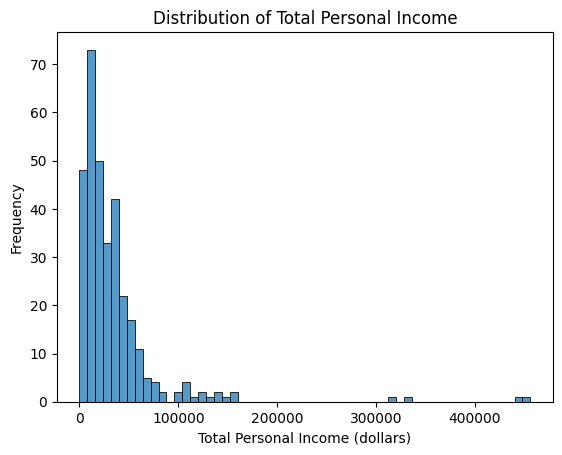

In [42]:
sns.histplot(df["total_personal_income"])
plt.xlabel("Total Personal Income (dollars)")
plt.ylabel("Frequency")
plt.title("Distribution of Total Personal Income")
plt.show()

In [43]:
df["total_personal_income"].describe()

,total_personal_income
count,326.000000
mean,34772.380368
std,48582.334072
min,90.000000
25%,12000.000000
50%,23500.000000
75%,40000.000000
max,456000.000000


This histogram is skewed right with outliers very far out. The data shows that a majority of people in the year 2000 earned around 30,000 to 40,000 dollars in total that year. This makes sense since according the the U.S. Census Bereau the median income in 2000 was $42,148. There are a very few amount of people who made over 500,000 dollars and an even smaller amount who even made over 100,000 dollars.

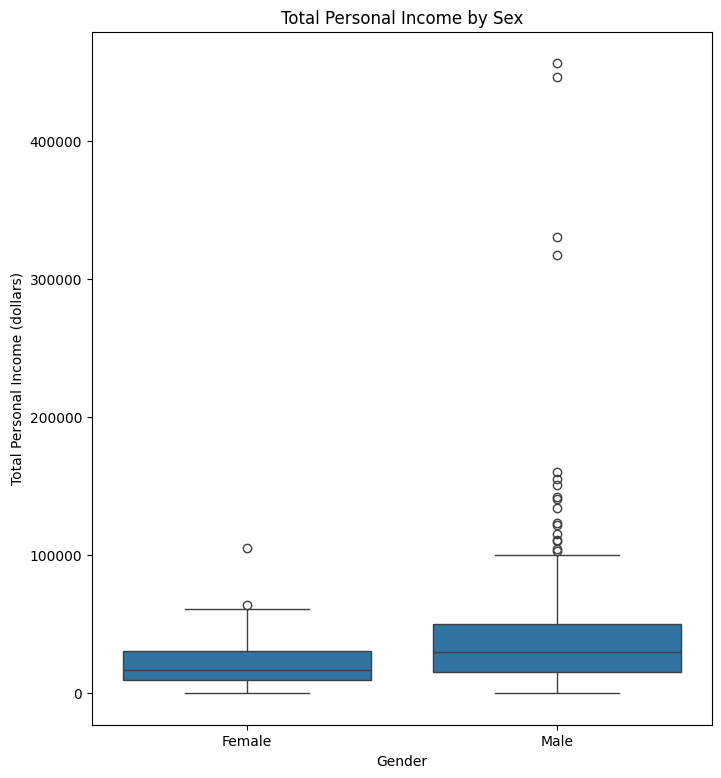

In [44]:
plt.figure(figsize=(8, 9))
sns.boxplot(x="sex", y="total_personal_income", data=df)
plt.xlabel("Gender")
plt.ylabel("Total Personal Income (dollars)")
plt.title("Total Personal Income by Sex")
plt.show()

This boxplot shows the distribution of personal income by sex. Males have a higher median around 40,000 dollars while female have a median around 20,000 dollars.  The spread of the boxplot for males is also larger than the one for females showing that in 2000 men tended to make more on average than women. Men also have more outliers in the higher income earned.

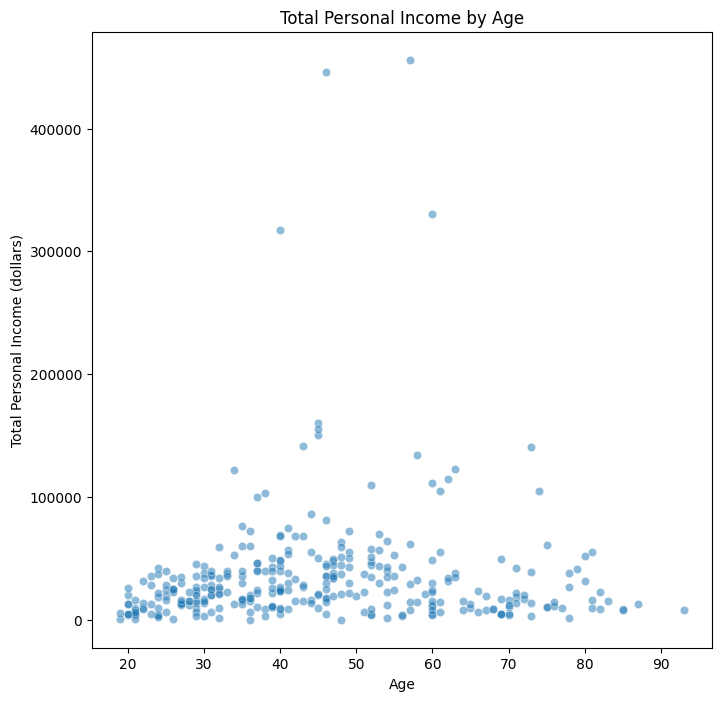

In [45]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x="age", y="total_personal_income", alpha=0.5, data=df)
plt.xlabel("Age")
plt.ylabel("Total Personal Income (dollars)")
plt.title("Total Personal Income by Age")
plt.show()

This scatterplot shows the distribution of income by age. Between 18 and 60 people tended to make similar incomes the the distribution of data points being similar throught this range. Although, between 30 to 60 years old there is slightly more people that can be seen with higher income as can be seen with some of the data points between these ages being greater. After 60 the data shows that income seems to get lower which would make sense as many people stop working at these ages and retire.

### b. Train/Test Split  

Split your data into:

- Training set  
- Testing set  

Explain your choice (e.g., 80/20 split).

In [46]:
df["personal_income"] = (df["total_personal_income"] > df["total_personal_income"].median()).astype(int)

X = df[["sex", "age"]]
y = df["personal_income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

### c. Build a Baseline Model  

Build a **linear regression model** using your selected variables.

Explain:

- What variables you included  
- Why you chose them

In [47]:
model = smf.logit(
    "personal_income ~ age + C(sex)", data=df
).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.666901
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:        personal_income   No. Observations:                  326
Model:                          Logit   Df Residuals:                      323
Method:                           MLE   Df Model:                            2
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                 0.03787
Time:                        06:58:57   Log-Likelihood:                -217.41
converged:                       True   LL-Null:                       -225.97
Covariance Type:            nonrobust   LLR p-value:                 0.0001923
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.4194      0.346     -1.211      0.226      -1.098       0.260
C(sex)[T.Male]   

### d. Improve Your Model  

Modify your model using at least **ONE** of the following:

- Transformation (log, polynomial, etc.)  
- Interaction term  
- Feature selection (adding/removing variables)  

You must:

- Explain **why** you made the change  
- Support your decision using:
  - plots  
  - patterns in the data  
  - model results

In [48]:
model = smf.logit(
    "personal_income ~ age + C(sex) + C(race_general) + C(state_fips_code)", data=df
).fit()
print(model.summary())

         Current function value: 0.577223
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:        personal_income   No. Observations:                  326
Model:                          Logit   Df Residuals:                      273
Method:                           MLE   Df Model:                           52
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                  0.1672
Time:                        06:58:57   Log-Likelihood:                -188.17
converged:                      False   LL-Null:                       -225.97
Covariance Type:            nonrobust   LLR p-value:                   0.01800
                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------
Intercept                                             -0.3328   

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


I added in race and states as variables to see if the state someone lived in or their race played a part in determining a persons total income since the persons age wasn't statistically significant. However, none of the races or states had a p-value less than 0.05 meaning that they most likely didn't play a factor in determining a persons total income.

### e. Compare Models  

Compare your baseline and improved models using appropriate metrics:

- RMSE  
- \(R^2\)

Clearly explain:

- Which model performs better  
- Why

### f. Interpret Your Final Model  

Explain your regression model in plain language:

- Which variables are important?  
- What do the coefficients mean?  
- How do predictors affect the response variable?

### g. Predictions  

Use your final model to:

- Make predictions for **3 new data points**  
- Interpret the results in context

---
## **Conclusions and Recommendations**

Summarize:

- Key findings  
- Model performance  
- Any challenges or limitations  
- Whether your model generalizes well  
- Possible next steps or improvements  

If results are not strong or interesting, explain why.